#**유통 판매량 예측 및 재고 최적화**
## **단계3 : 모델링 및 비즈니스 평가**

# **0.미션**

* 단계1 다양한 모델링 수행
    * LSTM, CNN 등을 이용해서 다양한 시계열 모델링 수행
    * 성능 상위 2~3개 모델 선정
* 단계2 데이터 파이프라인 구축
    * test 데이터(raw data)로 부터 예측에 사용할 수 있는 형태로 데이터를 만드는 과정을 하나의 함수로 엮기
* 단계3 비즈니스 평가
    * 단계1에서 선정된 모델에 대해 test셋으로 평균 재고액 평가 수행

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/AIVLE/mini_project_5/'

### **(2) 라이브러리 설치 및 불러오기**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

import keras
from keras.models import Sequential
from keras.backend import clear_session
from keras.layers import Dense, LSTM, Conv1D, Flatten, Bidirectional
from keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install holidays

In [ ]:
import holidays

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

In [ ]:
# 평가지표
def get_metrics(y_val, y_pred):
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    print(f'RMSE : {rmse:.4f}')
    print(f'MAE : {mae:.4f}')
    print(f'MAPE : {mape:.4f}')
    print(f'R2 : {r2:.4f}')

    return rmse, mae, mape, r2

In [ ]:
# Climate data.csv 전처리
def preprocessing_climate(climates_test):
    climate = climates_test.copy()

    climate['Date'] = pd.to_datetime(climate['Date'])
    climate = climate.set_index('Date')
    climate.replace('T', np.nan, inplace=True)
    climate = climate.astype('float64')
    climate = climate.interpolate(method='linear')
    climate = climate.fillna(0)
    climate = climate[['Maximum Temperature degrees (F)', 'Minimum Temperature degrees (F)', 'Precipitation (inches)']]

    # 기후 데이터를 필요한 부분으로 편집
    climate_ = pd.DataFrame(index=climate.index)
    climate_['Max Temp'] = climate['Maximum Temperature degrees (F)']
    climate_['Min Temp'] = climate['Minimum Temperature degrees (F)']
    climate_['Precipitation (inches)'] = climate['Precipitation (inches)']
    climate_[f'accum{30}.Prec.'] = climate['Precipitation (inches)'].rolling(window=30).sum()
    climate_[f'accum{60}.Prec.'] = climate['Precipitation (inches)'].rolling(window=60).sum()
    climate_[f'accum{90}.Prec.'] = climate['Precipitation (inches)'].rolling(window=90).sum()
    climate_[f'accum{120}.Prec.'] = climate['Precipitation (inches)'].rolling(window=120).sum()

    return climate_

### **(3) 데이터 불러오기**

In [ ]:
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
stores = pd.read_csv(path + 'train/stores.csv')
climates = pd.read_csv(path + 'Climate data.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

* **세부 요구사항**
    - 상품별로 저장한 데이터를 불러오시오.

In [ ]:
# Load Beverage Dataset
def load_bev_df(sales, orders, climates, oil_price):
    store_id = 44

    df = sales[(sales['Store_ID'] == store_id) & (sales['Product_ID'] == 3)][['Date', 'Qty']]
    df = df.set_index('Date')
    df['Qty_2day'] = df['Qty'].shift(-2).dropna()  # y, target

    df.index = pd.to_datetime(df.index)

    df['dow'] = df.index.dayofweek
    df['dow'] = df['dow'].map({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})

    orders_ = orders.set_index('Date')
    df['Num_Customer'] = orders_[orders_['Store_ID'] == store_id]['CustomerCount']
    df['Num_Customer'].interpolate(method='linear', inplace=True)
    df['Num_Customer'].fillna(method='bfill', inplace=True)
    df['Num_Customer'] = df['Num_Customer'].astype('int')

    steps = [1, 7, 15, 30]
    for step in steps:
        daily_sales_change = df['Qty'].diff(step).fillna(0)
        df[f'diff_step{step}'] = daily_sales_change
        daily_sales_change = df['Qty'].shift(step).fillna(0)
        df[f'shift_step{step}'] = daily_sales_change

    climates_ = preprocessing_climate(climates)
    df = pd.merge(df, climates_, on='Date', how='left')

    prod_target = products[products['Category'] == 'Drink']
    id_list = prod_target['Product_ID'].tolist()
    names = prod_target['SubCategory'].tolist()
    temp = sales[(sales['Store_ID'] == store_id) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
    df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
    df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
    df2.columns = names
    df['Wine'] = df2['Wine']

    oil_price_ = oil_price.copy()
    oil_price_ = oil_price_.set_index('Date')
    df['WTI_Price'] = oil_price_['WTI_Price']
    df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
    df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]

    df = pd.get_dummies(df, columns = ['dow'], drop_first = True)

    return df


In [ ]:
# Beverage Dateset
load_bev_df(sales, orders, climates, oil_price).head()

,Qty,Qty_2day,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,diff_step30,...,accum90.Prec.,accum120.Prec.,Wine,WTI_Price,dow_Mon,dow_Sat,dow_Sun,dow_Thu,dow_Tue,dow_Wed
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,8647.0,4422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.865000,7.235000,0.0,95.14,False,False,False,False,False,True
2014-01-02,9853.0,15153.0,4422,9853.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.575000,7.235000,9853.0,95.14,False,False,False,True,False,False
2014-01-03,8647.0,15606.0,4167,-1206.0,9853.0,0.0,0.0,0.0,0.0,0.0,...,4.685000,7.355000,8647.0,93.66,False,False,False,False,False,False
2014-01-04,15153.0,7900.0,5341,6506.0,8647.0,0.0,0.0,0.0,0.0,0.0,...,4.655000,7.375000,15153.0,93.48,False,True,False,False,False,False
2014-01-05,15606.0,7188.0,5123,453.0,15153.0,0.0,0.0,0.0,0.0,0.0,...,4.668333,7.388333,15606.0,93.30,False,False,True,False,False,False


In [ ]:
# Load Milk Dataset
def load_milk_df(sales, climates):
    store_id = 44
    product_id = 12

    df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
    df = df.set_index('Date')
    df['Qty_1day'] = df['Qty'].shift(-1).dropna()
    df['Qty_2day'] = df['Qty'].shift(-2).dropna()
    df.dropna(axis=0, inplace=True)
    df.index = pd.to_datetime(df.index)

    # Day of week
    df['dow'] = df.index.dayofweek
    df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

    # Number of Customer
    orders_ = orders.set_index('Date')
    df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
    df['Num_Customer'].interpolate(method='linear', inplace=True)
    df['Num_Customer'].fillna(method='bfill', inplace=True)
    df['Num_Customer'] = df['Num_Customer'].astype('int')

    # Shift and Diff
    steps = [1, 7, 15, 30]
    for step in steps:
        daily_sales_change = df['Qty'].diff(step).fillna(0)
        df[f'diff_step{step}'] = daily_sales_change
        daily_sales_change = df['Qty'].shift(step).fillna(0)
        df[f'shift_step{step}'] = daily_sales_change

    # Climate Data
    climates_ = preprocessing_climate(climates)
    df = pd.merge(df, climates_, on='Date', how='left')

    df = pd.get_dummies(df, columns = ['dow'], drop_first = True)

    return df

In [ ]:
load_milk_df(sales, climates).head()

,Qty,Qty_1day,Qty_2day,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,...,accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.,dow_Mon,dow_Sat,dow_Sun,dow_Thu,dow_Tue,dow_Wed
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,9647.0,8879.0,4422,0.0,0.0,0.0,0.0,0.0,0.0,...,1.990000,2.630000,4.865000,7.235000,False,False,False,False,False,True
2014-01-02,9647.0,8879.0,14188.0,4422,9647.0,0.0,0.0,0.0,0.0,0.0,...,1.910000,2.630000,4.575000,7.235000,False,False,False,True,False,False
2014-01-03,8879.0,14188.0,14490.0,4167,-768.0,9647.0,0.0,0.0,0.0,0.0,...,1.510000,2.580000,4.685000,7.355000,False,False,False,False,False,False
2014-01-04,14188.0,14490.0,7614.0,5341,5309.0,8879.0,0.0,0.0,0.0,0.0,...,1.270000,2.420000,4.655000,7.375000,False,True,False,False,False,False
2014-01-05,14490.0,7614.0,7124.0,5123,302.0,14188.0,0.0,0.0,0.0,0.0,...,1.283333,2.383333,4.668333,7.388333,False,False,True,False,False,False


In [ ]:
# Load Agricultural products
def load_ag_df(sales, climates):
    # 기본 데이터 셋 불러오기
    store_id = 44
    product_id = 42
    df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
    df = df.set_index('Date')
    df['Qty_1day'] = df['Qty'].shift(-1).dropna()
    df['Qty_2day'] = df['Qty'].shift(-2).dropna()
    df.dropna(axis=0, inplace=True)
    df.index = pd.to_datetime(df.index)

    # Day of week
    df['dow'] = df.index.dayofweek
    df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

    # Number of Customer
    orders_ = orders.set_index('Date')
    df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
    df['Num_Customer'].interpolate(method='linear', inplace=True)
    df['Num_Customer'].fillna(method='bfill', inplace=True)
    df['Num_Customer'] = df['Num_Customer'].astype('int')

    # Shift and Diff
    steps = [1, 7, 15, 30]
    for step in steps:
        daily_sales_change = df['Qty'].diff(step).fillna(0)
        df[f'diff_step{step}'] = daily_sales_change
        daily_sales_change = df['Qty'].shift(step).fillna(0)
        df[f'shift_step{step}'] = daily_sales_change

    # Climate Data
    climates_ = preprocessing_climate(climates)
    df = pd.merge(df, climates_, on='Date', how='left')

    df = pd.get_dummies(df, columns = ['dow'], drop_first = True)

    return df

In [ ]:
load_ag_df(sales, climates).head()

,Qty,Qty_1day,Qty_2day,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,...,accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.,dow_Mon,dow_Sat,dow_Sun,dow_Thu,dow_Tue,dow_Wed
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,51.0,76.0,74.0,4422,0.0,0.0,0.0,0.0,0.0,0.0,...,1.990000,2.630000,4.865000,7.235000,False,False,False,False,False,True
2014-01-02,76.0,74.0,78.0,4422,25.0,51.0,0.0,0.0,0.0,0.0,...,1.910000,2.630000,4.575000,7.235000,False,False,False,True,False,False
2014-01-03,74.0,78.0,88.0,4167,-2.0,76.0,0.0,0.0,0.0,0.0,...,1.510000,2.580000,4.685000,7.355000,False,False,False,False,False,False
2014-01-04,78.0,88.0,65.0,5341,4.0,74.0,0.0,0.0,0.0,0.0,...,1.270000,2.420000,4.655000,7.375000,False,True,False,False,False,False
2014-01-05,88.0,65.0,78.0,5123,10.0,78.0,0.0,0.0,0.0,0.0,...,1.283333,2.383333,4.668333,7.388333,False,False,True,False,False,False


# **2.모델링**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.
    * 데이터 파이프라인 함수 작성하기
        * input : raw data
        * output : x_train, x_val, y_train, y_val
        * 원본 데이터에서 일부를 떼어 놓고, 파이프라인 함수를 테스트 해 봅시다.

In [ ]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

## **(1) LSTM 모델링**

In [ ]:
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, SimpleRNN, LSTM, Flatten, Input, Dropout, BatchNormalization
from keras.backend import clear_session
from keras.optimizers import Adam

from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [ ]:
bev_df = load_bev_df(sales, orders, climates, oil_price)

target = 'Qty_2day'
x_bev = bev_df.drop(columns=[target])
y_bev = bev_df[target]

bev_df = bev_df.sort_values(by='Date').reset_index(drop=True)

timesteps = 7  # 차원 수 = 입력할 날짜 수
x_temporal_bev, y_temporal_bev = temporalize(x_bev, y_bev, timesteps)

# 결과 확인
print(f"x_temporal shape: {x_temporal_bev.shape}")
print(f"y_temporal shape: {y_temporal_bev.shape}")

x_temporal shape: (1146, 7, 25)
y_temporal shape: (1146,)


In [ ]:
# 스케일링
x_train_bev, x_val_bev = x_temporal_bev[:-60], x_temporal_bev[-60:]
y_train_bev, y_val_bev = y_temporal_bev[:-60], y_temporal_bev[-60:]
y_val_bev = np.nan_to_num(y_val_bev, nan=0)

sc_bev = MinMaxScaler()
x_train_bev = sc_bev.fit_transform(x_train_bev.reshape(-1, x_train_bev.shape[-1])).reshape(x_train_bev.shape)
x_val_bev = sc_bev.transform(x_val_bev.reshape(-1, x_val_bev.shape[-1])).reshape(x_val_bev.shape)

sc_y_bev = MinMaxScaler()
y_train_bev_scaled = sc_y_bev.fit_transform(y_train_bev.reshape(-1, 1)).ravel()
y_val_bev_scaled = sc_y_bev.transform(y_val_bev.reshape(-1, 1)).ravel()


* **모델링**

In [ ]:
clear_session()

timesteps = x_temporal_bev.shape[1]
nfeatures = x_temporal_bev.shape[2]

print(timesteps, nfeatures)

inp = Input(shape=(timesteps, nfeatures))

x = LSTM(32, activation='tanh', return_sequences=True)(inp)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = LSTM(64, activation='tanh')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

out = Dense(1)(x)

lstm_bev = Model(inp, out)
lstm_bev.compile(loss='mse', optimizer=Adam(learning_rate=0.0025))

lstm_bev.summary()

7 25


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7, 25)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 7, 32)               │           7,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,425 (154.00 KB)

 Trainable params: 39,233 (153.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
save_path = path + 'models/' + 'bev_lstm_1_best.keras'
mc = ModelCheckpoint(save_path, save_best_only=True)

his_bev = lstm_bev.fit(
    x_train_bev,
    y_train_bev_scaled,
    epochs=1000,
    batch_size=64,
    validation_data=(x_val_bev, y_val_bev_scaled),
    callbacks=[es, mc],
)

Epoch 1/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0611 - val_loss: 0.1653
Epoch 2/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0222 - val_loss: 0.1470
Epoch 3/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0160 - val_loss: 0.1382
Epoch 4/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0112 - val_loss: 0.1248
Epoch 5/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0095 - val_loss: 0.1224
Epoch 6/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - val_loss: 0.1185
Epoch 7/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0078 - val_loss: 0.1118
Epoch 8/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.1012
Epoch 9/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075 - val_loss: 0.1033
Epoch 10/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - val_loss: 0.0963
Epoch 11/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075 - val_loss: 0.0920
Epoch 12/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 

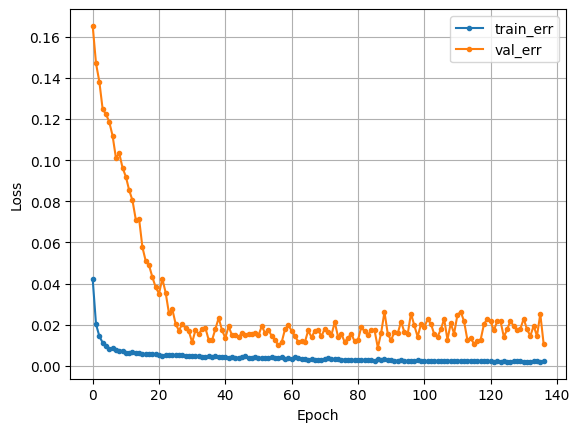

In [ ]:
dl_history_plot(his_bev.history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
RMSE : 0.0938
MAE : 0.0621
MAPE : 48319261206118.5156
R2 : 0.6808


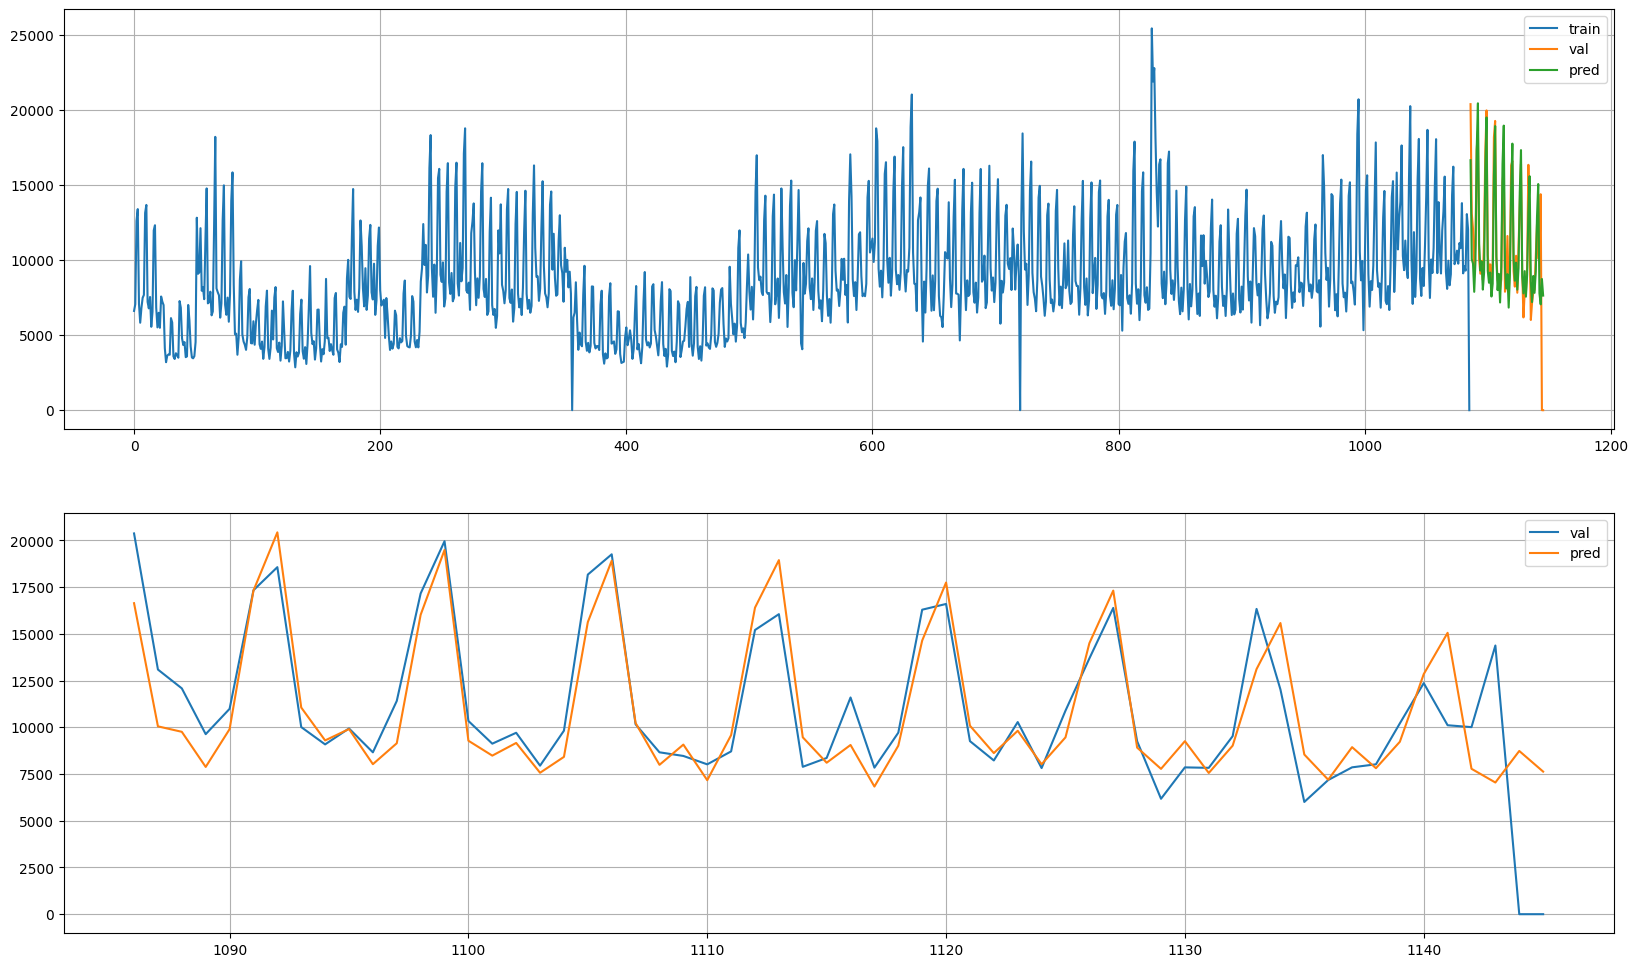

In [ ]:
y_pred_bev = lstm_bev.predict(x_val_bev)
get_metrics(y_val_bev_scaled, y_pred_bev)

y_pred_bev = sc_y_bev.inverse_transform(y_pred_bev)
plot_model_result(y_train_bev, y_val_bev, y_pred_bev)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [ ]:
milk_df = load_milk_df(sales, climates)

target = 'Qty_2day'
x_milk = milk_df.drop(columns=[target])
y_milk = milk_df[target]

milk_df = milk_df.sort_values(by='Date').reset_index(drop=True)

timesteps = 7  # 차원 수 = 입력할 날짜 수
x_temporal_milk, y_temporal_milk = temporalize(x_milk, y_milk, timesteps)

# 결과 확인
print(f"x_temporal shape: {x_temporal_milk.shape}")
print(f"y_temporal shape: {y_temporal_milk.shape}")

x_temporal shape: (1144, 7, 24)
y_temporal shape: (1144,)


In [ ]:
# 스케일링
x_tr_milk, x_val_milk = x_temporal_milk[:-60], x_temporal_milk[-60:]
y_tr_milk, y_val_milk = y_temporal_milk[:-60], y_temporal_milk[-60:]
y_val_milk = np.nan_to_num(y_val_milk, nan=0)

sc_milk = MinMaxScaler()
x_tr_milk = sc_milk.fit_transform(x_tr_milk.reshape(-1, x_tr_milk.shape[-1])).reshape(x_tr_milk.shape)
x_val_milk = sc_milk.transform(x_val_milk.reshape(-1, x_val_milk.shape[-1])).reshape(x_val_milk.shape)

sc_y_milk = MinMaxScaler()
y_tr_milk_scaled = sc_y_milk.fit_transform(y_tr_milk.reshape(-1, 1)).ravel()
y_val_milk_scaled = sc_y_milk.transform(y_val_milk.reshape(-1, 1)).ravel()

* **모델링**

In [ ]:
clear_session()

timesteps = x_temporal_milk.shape[1]
nfeatures = x_temporal_milk.shape[2]

inp = Input(shape=(timesteps, nfeatures))

x = LSTM(32, activation='tanh', return_sequences=True)(inp)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = LSTM(64, activation='tanh')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

out = Dense(1)(x)

lstm_milk = Model(inp, out)
lstm_milk.compile(loss='mse', optimizer=Adam(learning_rate=0.0025))

lstm_milk.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7, 24)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 7, 32)               │           7,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,297 (153.50 KB)

 Trainable params: 39,105 (152.75 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
save_path = path + 'models/' + 'milk_lstm_best.keras'
mc = ModelCheckpoint(save_path, save_best_only=True)

his_milk = lstm_milk.fit(
    x_tr_milk,
    y_tr_milk_scaled,
    epochs=1000,
    batch_size=64,
    validation_data=(x_val_milk, y_val_milk_scaled),
    callbacks=[es, mc],
)

Epoch 1/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.2514 - val_loss: 0.0662
Epoch 2/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0160 - val_loss: 0.0594
Epoch 3/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0102 - val_loss: 0.0542
Epoch 4/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0106 - val_loss: 0.0503
Epoch 5/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0079 - val_loss: 0.0469
Epoch 6/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - val_loss: 0.0403
Epoch 7/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0076 - val_loss: 0.0389
Epoch 8/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075 - val_loss: 0.0368
Epoch 9/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0369
Epoch 10/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - val_loss: 0.0357
Epoch 11/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0063 - val_loss: 0.0325
Epoch 12/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 

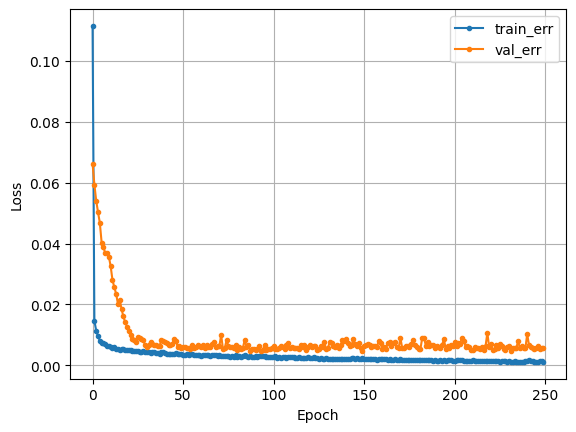

In [ ]:
dl_history_plot(his_milk.history)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
RMSE : 0.0691
MAE : 0.0501
MAPE : 24897690533888.1523
R2 : 0.4650


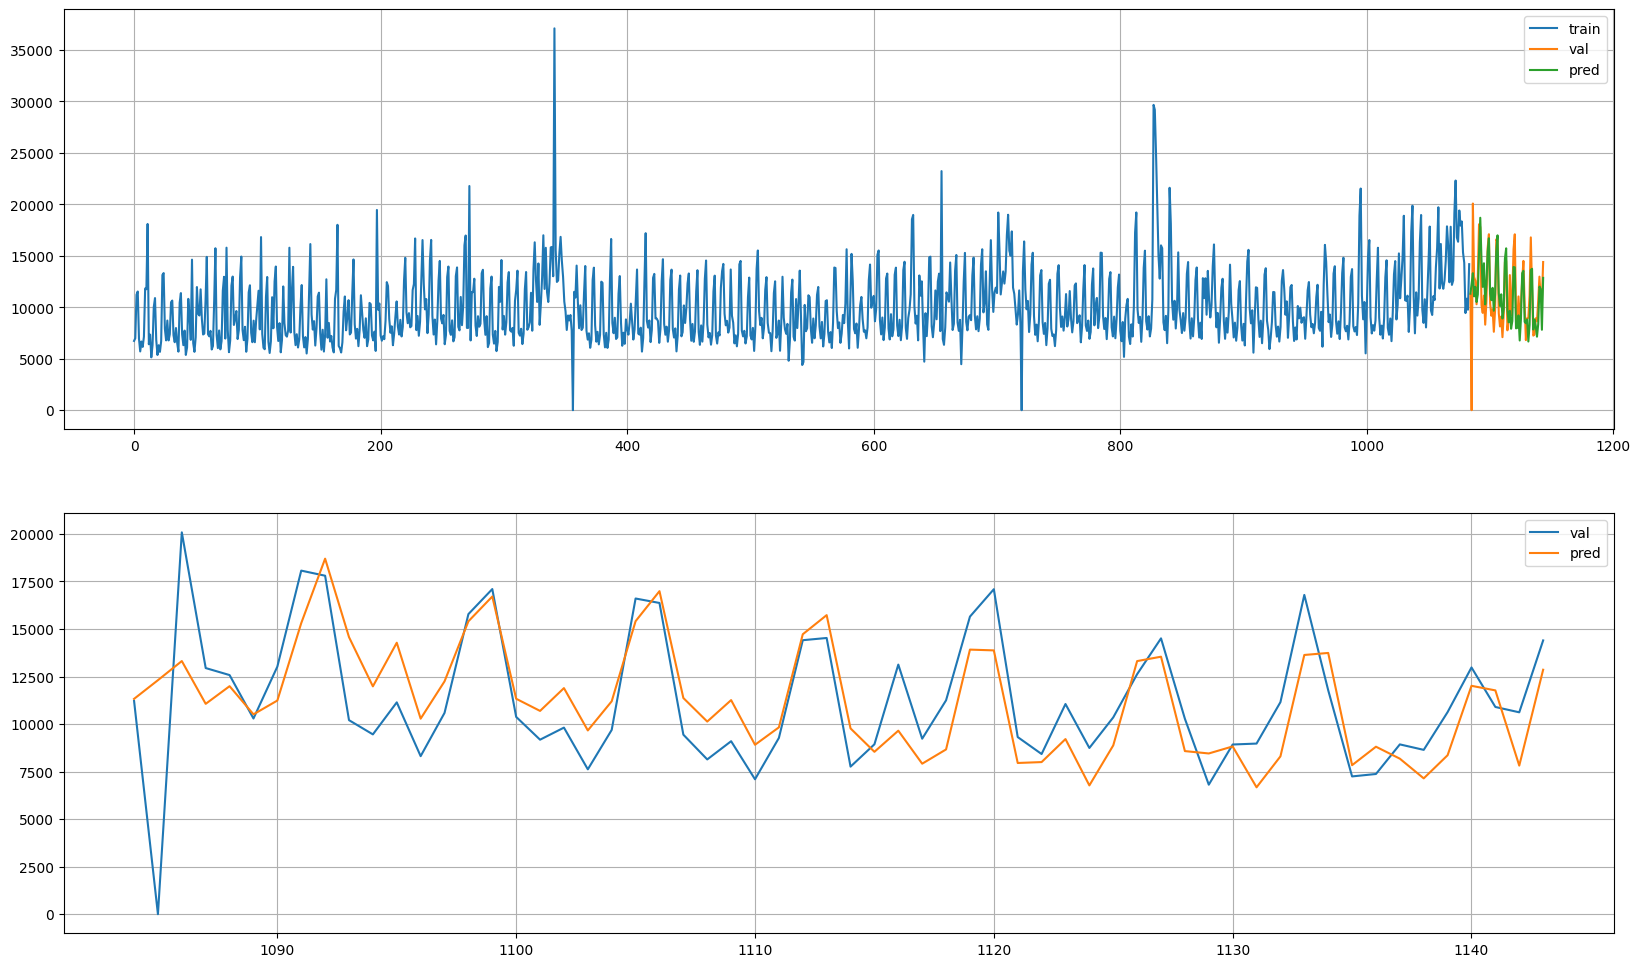

In [ ]:
y_pred_milk = lstm_milk.predict(x_val_milk)
get_metrics(y_val_milk_scaled, y_pred_milk)

y_pred_milk = sc_y_milk.inverse_transform(y_pred_milk)
plot_model_result(y_tr_milk, y_val_milk, y_pred_milk)

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

In [ ]:
ag_df = load_ag_df(sales, climates)

target = 'Qty_2day'
ag_x = ag_df.drop(columns=[target])
ag_y = ag_df[target]

ag_df = ag_df.sort_values(by='Date').reset_index(drop=True)

timesteps = 7  # 차원 수 = 입력할 날짜 수
x_temporal_ag, y_temporal_ag = temporalize(ag_x, ag_y, timesteps)

# 결과 확인
print(f"x_temporal shape: {x_temporal_ag.shape}")
print(f"y_temporal shape: {y_temporal_ag.shape}")

x_temporal shape: (1147, 7, 24)
y_temporal shape: (1147,)


In [ ]:
# 스케일링
x_tr_ag, x_val_ag = x_temporal_ag[:-60], x_temporal_ag[-60:]
y_tr_ag, y_val_ag = y_temporal_ag[:-60], y_temporal_ag[-60:]
y_val_ag = np.nan_to_num(y_val_ag, nan=0)

sc_ag = MinMaxScaler()
x_tr_ag = sc_ag.fit_transform(x_tr_ag.reshape(-1, x_tr_ag.shape[-1])).reshape(x_tr_ag.shape)
x_val_ag = sc_ag.transform(x_val_ag.reshape(-1, x_val_ag.shape[-1])).reshape(x_val_ag.shape)

sc_y_ag = MinMaxScaler()
y_tr_ag_scaled = sc_y_ag.fit_transform(y_tr_ag.reshape(-1, 1)).ravel()
y_val_ag_scaled = sc_y_ag.transform(y_val_ag.reshape(-1, 1)).ravel()

* **모델링**

In [ ]:
clear_session()

timesteps = x_temporal_ag.shape[1]
nfeatures = x_temporal_ag.shape[2]

inp = Input(shape=(timesteps, nfeatures))

x = LSTM(32, activation='tanh', return_sequences=True)(inp)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = LSTM(64, activation='tanh', return_sequences=True)(inp)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = LSTM(64, activation='tanh')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(8, activation='relu')(x)
x = Dropout(0.2)(x)

out = Dense(1)(x)

lstm_ag = Model(inp, out)
lstm_ag.compile(loss='mse', optimizer=Adam(learning_rate=0.0025))

lstm_ag.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7, 24)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 7, 64)               │          22,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,345 (231.82 KB)

 Trainable params: 59,089 (230.82 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)
save_path = path + 'models/' + 'ag_lstm_best.keras'
mc = ModelCheckpoint(save_path, save_best_only=True)

his_ag = lstm_ag.fit(
    x_tr_ag,
    y_tr_ag_scaled,
    epochs=1000,
    batch_size=64,
    validation_data=(x_val_ag, y_val_ag_scaled),
    callbacks=[es, mc],
)

Epoch 1/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.1966 - val_loss: 0.0285
Epoch 2/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0536 - val_loss: 0.0170
Epoch 3/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0373 - val_loss: 0.0145
Epoch 4/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0245 - val_loss: 0.0129
Epoch 5/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0253 - val_loss: 0.0129
Epoch 6/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0259 - val_loss: 0.0117
Epoch 7/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0202 - val_loss: 0.0115
Epoch 8/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0212 - val_loss: 0.0104
Epoch 9/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0198 - val_loss: 0.0097
Epoch 10/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0175 - val_loss: 0.0092
Epoch 11/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0168 - val_loss: 0.0086
Epoch 12/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 

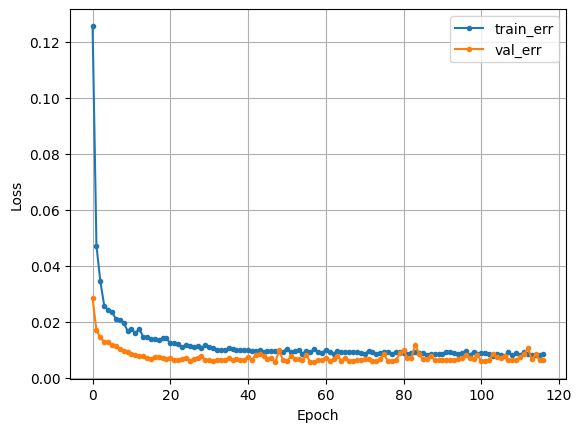

In [ ]:
dl_history_plot(his_ag.history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
RMSE : 0.1028
MAE : 0.0840
MAPE : 0.3984
R2 : -0.0474


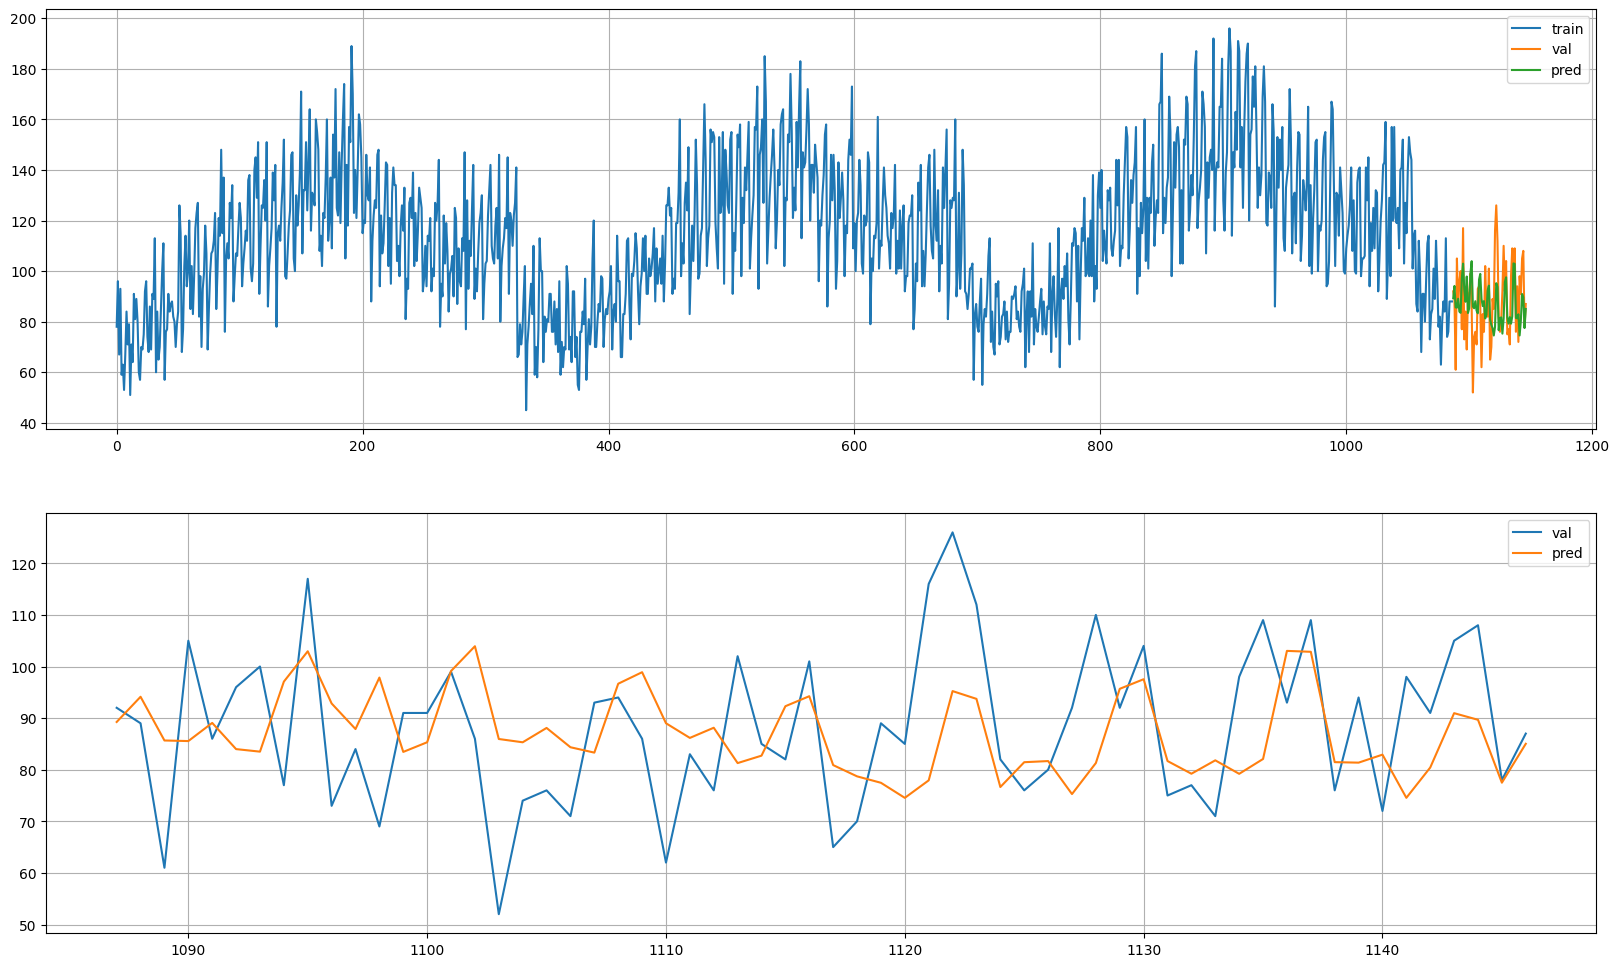

In [ ]:
y_pred_ag = lstm_milk.predict(x_val_ag)
get_metrics(y_val_ag_scaled, y_pred_ag)

y_pred_ag = sc_y_ag.inverse_transform(y_pred_ag)
plot_model_result(y_tr_ag, y_val_ag, y_pred_ag)

## **(2) CNN 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

* **모델링**

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

# **3.데이터 파이프라인 생성**

* 세부 요구사항
    * 데이터 파이프라인 함수 작성하기
        * input : raw data(sales_test, orders_test, oil_price_test, products, stores)
        * output : x_test, y_test
        * test set으로 파이프라인 함수를 테스트 해 봅시다.

## **(1) 파이프라인 함수 생성**

In [ ]:
# 데이터셋 불러오기
def pipeline(product_ID, sales, climates, orders, oil_price) :
    if (product_ID == 3):
        return load_bev_df(sales, orders, climates, oil_price)
    elif (product_ID == 12):
        return load_milk_df(sales, climates)
    elif (product_ID == 42):
        return load_ag_df(sales, climates)

In [ ]:
# 모델 평가 함수

def eval_model(model_path, x_sc, y_sc, sales_test, climates, oil_price_test, product_ID = 3, timesteps = 7):
    test_model = keras.models.load_model(model_path)

    x_test, y_test = preprocessing4predict(sales_test, climates, oil_price_test, product_ID, timesteps)

    x_test = x_sc.transform(x_test.reshape(-1, x_test.shape[-1])).reshape(x_test.shape)
    y_pred_scaled_test = test_model.predict(x_test)
    y_pred_test = y_sc.inverse_transform(y_pred_scaled_test) # 리버스 스케일링

    # 평가 지표 및 그래프
    get_metrics(y_test, y_pred_test)

    # 평가 그래프 출력
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label = 'real')
    plt.plot(y_pred_test, label = 'pred')
    plt.legend()
    plt.grid()

## **(2) test 데이터로 확인**

* test용 데이터셋들 로딩

In [ ]:
oil_price_test = pd.read_csv(path + 'test/oil_price_test.csv')
sales_test = pd.read_csv(path + 'test/sales_test.csv')
orders_test = pd.read_csv(path + 'test/orders_test.csv')
products = pd.read_csv(path + 'test/products.csv')
stores = pd.read_csv(path + 'test/stores.csv')
climates = pd.read_csv(path + 'Climate data.csv')

sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'])
orders_test['Date'] = pd.to_datetime(orders_test['Date'] )

In [ ]:
def preprocessing4predict(
        product_ID,

        sales_test,
        climates_test,
        orders_test,
        oil_price_test,

        timesteps = 7
    ):
    df = pipeline(product_ID, sales_test, climates_test, orders_test, oil_price_test)

    target = 'Qty_2day'
    x = df.drop(columns=[target])
    y = df[target]

    # 3D 데이터화
    x_test, y_test = temporalize(x, y, timesteps)

    return x_test, y_test

* 예측해보기

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
RMSE : 1661.5333
MAE : 1362.1682
MAPE : 0.1334
R2 : 0.8287


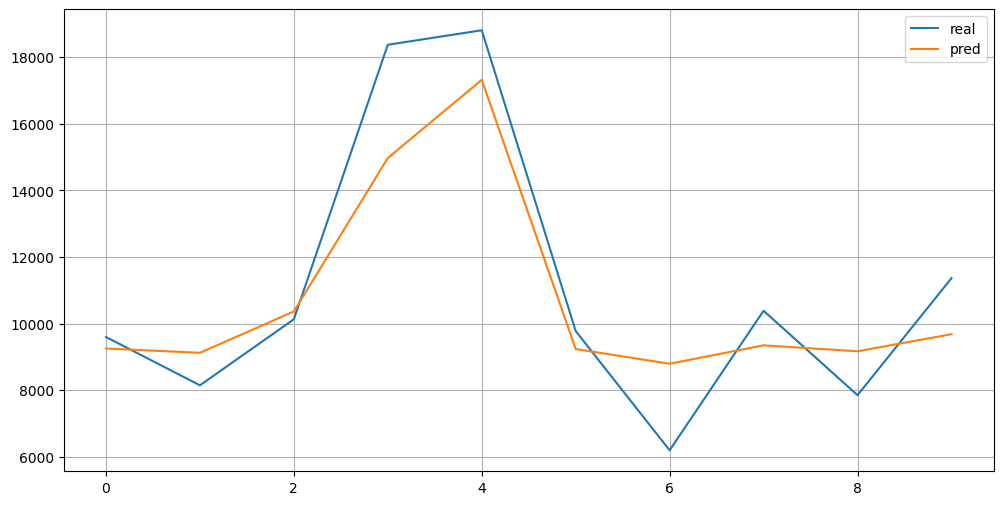

In [ ]:
# Beverage

best_model_path = '/content/drive/MyDrive/AIVLE/mini_project_5/models/bev_lstm_1_0.0728.keras' # 사용할 모델의 keras 경로
eval_model(best_model_path, sc_bev, sc_y_bev, sales_test, climates, oil_price_test, product_ID = 3, timesteps = 7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
RMSE : 1683.6581
MAE : 1212.1544
MAPE : 0.1372
R2 : 0.6939


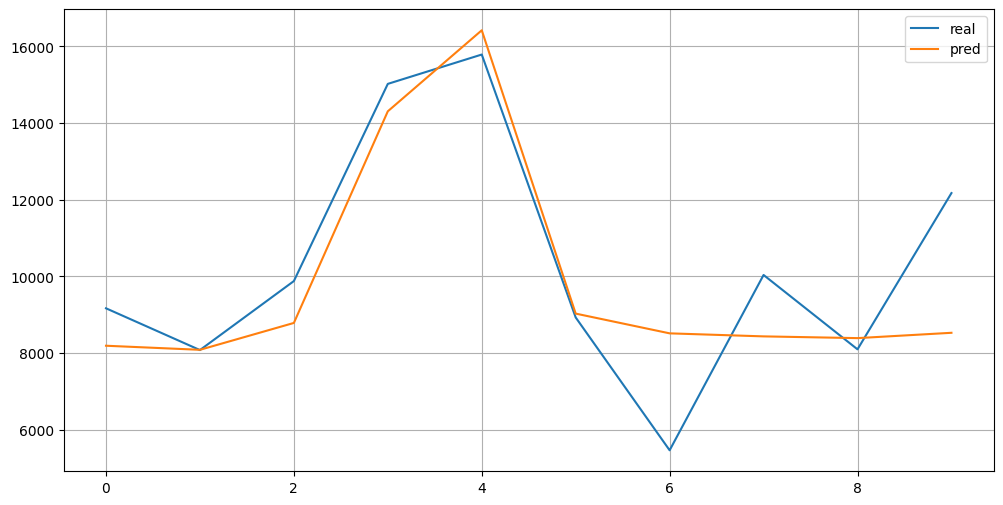

In [ ]:
# milk
best_model_path = '/content/drive/MyDrive/AIVLE/mini_project_5/models/milk_lstm_a.keras' # 사용할 모델의 keras 경로
eval_model(best_model_path, sc_milk, sc_y_milk, sales_test, climates, oil_price_test, product_ID = 12, timesteps = 7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
RMSE : 8641.7904
MAE : 8636.6137
MAPE : 81.7883
R2 : -469215.7757


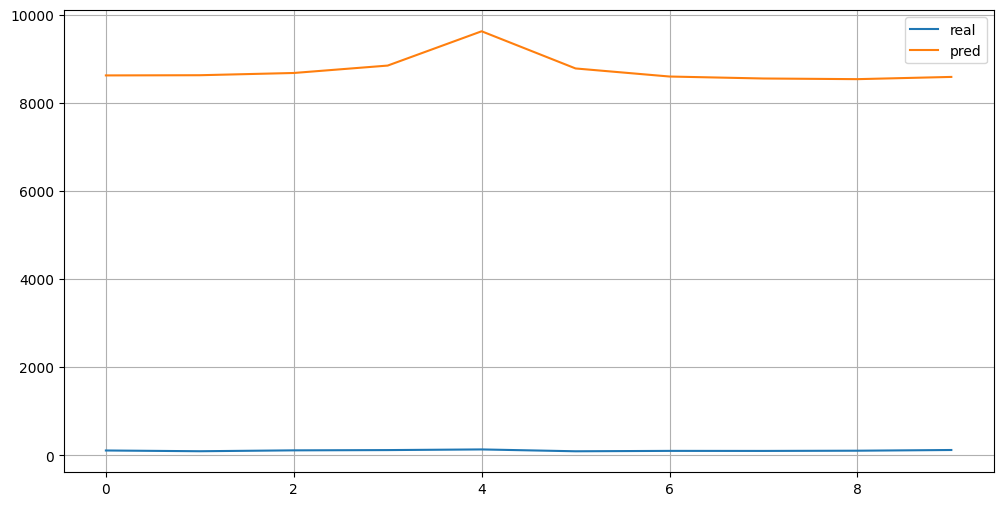

In [ ]:
# Agricultural products
best_model_path = '/content/drive/MyDrive/AIVLE/mini_project_5/models/ag_lstm_best.keras' # 사용할 모델의 keras 경로
eval_model(best_model_path, sc_ag, sc_y_ag, sales_test, climates, oil_price_test, product_ID = 42, timesteps = 7)

# **4.비즈니스 평가**

* 세부 요구사항
    * 기본 시뮬레이션 함수가 제공됩니다.
        * 필요하다면 해당 함수를 수정해서 사용할 수 있습니다.
    * 시뮬레이션 함수 사용하여 재고 평가
        * 실제값, 예측값, 안전재고 수량을 넣고 일평균 재고 금액을 확인합니다.
        * 기회손실수량은 0으로 맞추도록 안전재고 수량을 조절합니다.
        * 평균재고금액을 확인합니다.
    * 데이터는 test 셋을 이용합니다.
        * 예측 후 재고 평가 시, 스케일링된 y를 원래대로 돌려 놓아야 합니다.
            * y_real = y_sacled * (y_max - y_min) + y_min
            * pred_real = pred * (y_max - y_min) + y_min

## **(1) 재고 시뮬레이터**

In [ ]:
def inv_simulator(y, pred, safe_stock, price) :

    # 시뮬레이션 df 틀 만들기
    temp = pd.DataFrame({'y':y.reshape(-1,), 'pred':pred.reshape(-1,).round()})

    temp['base_stock'] = 0
    temp['close_stock'] = 0
    temp['order'] = 0
    temp['receive'] = 0

    # 시뮬레이션

    for i in range(len(temp)-2):  # 발주량은 leadtime 후 판매 예측량에 기초하므로 계산을 위해 마지막 leadtime 만큼의 행 제외
        if i == 0 : #첫 행. 2일 전 데이터가 없으므로,
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y']  # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + safe_stock  # 기초재고는 실판매량 + 안전재고로 계산

        elif i == 1 : # 둘째 행, 2일 전 데이터가 없음.
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y'] # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']
        else :      # 나머지 전체 행.
            temp.loc[ i ,'receive'] = temp.loc[ i-2 ,'order']    # 입고량 = 2일전 발주량
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']  # 기초재고 = 입고량 + 전날 기말재고

        # 기말재고 = 기초재고 - 판매량,  만약 0보다 작으면 0으로.
        stock = round(temp.loc[i, 'base_stock'] - temp.loc[i, 'y'])
        temp.loc[i, 'close_stock'] = np.where(stock> 0, stock, 0)

        # 발주량 = 2일후 판매예측량 + 안전재고 - 기말재고,  만약 주문량이 0보다 작으면 0
        order = temp.loc[i+2, 'pred'] + safe_stock - temp.loc[i, 'close_stock']
        temp.loc[i, 'order'] = np.where(order>0,order, 0)

    # 기회손실 = 만약 (기초재고 - 실판매량)이 0보다 작으면, 그만큼이 기회손실
    temp['lost'] = np.where((temp['base_stock'] - temp['y'])<0, (temp['base_stock'] - temp['y']),0).round()

    inventory = temp[:len(temp)-2]

    # 측정지표 계산
    DailyStock = ((inventory['base_stock'] + inventory['close_stock'])/2)
    DailyTurnover = (inventory['y'] + inventory['lost']) / DailyStock

    AvgDailyStock = round(DailyStock.mean(),3)
    AvgDailyStockAmt = AvgDailyStock * price
    turnover = round(DailyTurnover.mean(), 3)
    lost_sum = inventory['lost'].sum()


    print(f'일평균 재고량     : {AvgDailyStock}')
    print(f'일평균 재고 금액  : {AvgDailyStockAmt}')
    print(f'일평균 재고회전율 : {turnover}')
    print(f'기회손실 수량     : {lost_sum}')

    return inventory

## **(2) 예측 결과 시뮬레이션(재고금액 평가)**


In [1]:
inv = inv_simulator(y_test, y_pred_test, 12000, 8)

NameError: name 'inv_simulator' is not defined

In [ ]:
inv

,y,pred,base_stock,close_stock,order,receive,lost
0,9596.0,9096.0,9696,100,11188,9596,0.0
1,8146.0,9725.0,8246,100,12439,8146,0.0
2,10130.0,11188.0,11288,1158,11779,11188,0.0
3,18373.0,12439.0,13597,0,10893,12439,-4776.0
4,18808.0,12837.0,11779,0,9229,11779,-7029.0
5,9775.0,10793.0,10893,1118,8188,10893,0.0
6,6195.0,9129.0,10347,4152,5799,9229,0.0
7,10385.0,9206.0,12340,1955,9466,8188,0.0
